# Speed: saltjax vs sncosmo

This page measures how fast {func}`saltjax.fit_salt` is compared to `sncosmo.fit_lc`, on a realistic ZTF-like sample:
where the time goes on a first call and on later calls, how the cost scales with the number of SNe, and how to get the most out of it.
Every number below is measured in this notebook, on the machine described at the end of the page.

:::{note}
This page uses [skysurvey](https://github.com/MickaelRigault/skysurvey) with the real ZTF observing logs (`ztfcosmo` package)
and the SFD Milky Way dust map (`dustmaps`). The SN draw cannot be seeded in skysurvey yet, so the numbers change slightly from one run to the next.
:::

In [1]:
import os, sys, time, platform, subprocess, tempfile, warnings, functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import sncosmo
import ztfcosmo
import skysurvey
from skysurvey.lcfit import fit_salt as fit_salt_sncosmo
import saltjax
import saltjax.fit as sjfit

warnings.filterwarnings("ignore")   # sncosmo/skysurvey runtime warnings
rng = np.random.default_rng(42)

## A realistic dataset

We take 1.5 years of the real ZTF observing logs (this is what `skysurvey.ZTF.from_logs()` loads, restricted in time),
draw SNe Ia up to $z=0.06$ over the observed sky, with Milky Way extinction from the SFD map, and simulate their lightcurves.

In [2]:
logs = ztfcosmo.get_observing_logs()
mjd_start, mjd_stop = 58_300, 58_300 + 548        # ~1.5 years
logs = logs[(logs["mjd"] > mjd_start) & (logs["mjd"] < mjd_stop)]
ztf = skysurvey.ZTF.from_pointings(logs)           # as skysurvey.ZTF.from_logs(), on fewer logs
print(f"{len(ztf.data):,} quadrant observations")

17,748,777 quadrant observations


In [3]:
snia = skysurvey.SNeIa.from_draw(tstart=mjd_start + 20, tstop=mjd_stop - 50, zmax=0.06,
                                 skyarea=ztf.get_skyarea(), effect=skysurvey.Effect.from_name("mw"),
                                 mwebv={"which": "sfd"})
dset = skysurvey.DataSet.from_targets_and_survey(snia, ztf, phase_range=[-50, 100], seed=1)
dset.data["zpsys"] = "ab"                          # needed by sncosmo.fit_lc (not by saltjax)
ndet = dset.get_ndetection()
index = list(ndet[ndet >= 7].index)                # a good lightcurve: >= 7 detections
data, targets = dset.data.loc[index], dset.targets.data.loc[index]
print(f"{len(snia.data)} SNe Ia drawn, {len(index)} with >= 7 detections, {len(data):,} lightcurve points")

1512 SNe Ia drawn, 960 with >= 7 detections, 149,369 lightcurve points


The fit uses the points within the rest-frame phase range $[-10, 40]$ days (the default `phase_range`).
Their number varies a lot from one SN to the next, depending on the field cadence, the season and the redshift.
This matters for speed: saltjax groups lightcurves in **length buckets** (padded to 16, 32, 64, ... points, see below),
and each bucket is a separately compiled computation.

bucket (max points),16,32,64,128,256,512,1024
number of SNe,211,278,231,139,75,22,4


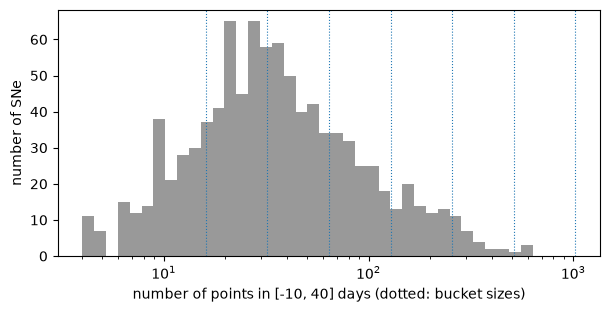

In [4]:
phase = (data["mjd"] - targets["t0"].reindex(data.index, level=0)) / (1 + targets["z"].reindex(data.index, level=0))
npts = phase.between(-10, 40).groupby(level=0).sum()
bucket = npts.map(lambda n: sjfit._next_pow(n, sjfit.LENGTH_BASE, 16))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(npts, bins=np.geomspace(4, npts.max() * 1.2, 40), color="0.6")
for L in np.unique(bucket):
    ax.axvline(L, color="C0", lw=0.8, ls=":")
ax.set_xscale("log")
ax.set_xlabel("number of points in [-10, 40] days (dotted: bucket sizes)")
ax.set_ylabel("number of SNe")
bucket.value_counts().sort_index().rename_axis("bucket (max points)").to_frame("number of SNe").T

## Why sncosmo is slow and saltjax is fast

`sncosmo.fit_lc` minimises the $\chi^2$ with iminuit, one SN at a time:

* each $\chi^2$ evaluation computes the SALT2 model on the full wavelength grid of every band: a 2D (phase, wavelength) interpolation
  of the model surfaces, then an integral through the filter, for every point;
* the minimiser uses numerical gradients, so it needs a few hundred $\chi^2$ calls per SN (more with `modelcov=True`, which refits several times);
* all of this runs in Python and NumPy, SN after SN.

saltjax computes the same model differently:

* **precomputed band integrals**: the model surfaces are integrated through the bands once, on a fine redshift grid
  ({func}`saltjax.get_tables`, cached); a model flux is then a small interpolation in phase and redshift;
* **exact gradients** from JAX automatic differentiation, in a Levenberg-Marquardt minimiser that needs few iterations;
* **all SNe at once**: the fit of one SN is vectorised over many SNe (`jax.vmap`);
* **compiled once**: the batched fit is compiled by XLA (`jax.jit`). Batches only depend on the bucket length (and `batch_points`),
  so the compiled functions are reused by any later call; on a first call the needed shapes are compiled ahead of time, in parallel threads;
* **length buckets**: lightcurves are padded to the next bucket length (16, 32, 64, ... points) rather than to the longest lightcurve,
  so short lightcurves do not pay for long ones.

## Where the time goes

### sncosmo

We fit a random subset of 150 SNe with `sncosmo.fit_lc` through skysurvey's `fit_salt`, with and without model covariance.
sncosmo starts from the true parameters, with wide bounds ($t_0\pm15$ days, $x_1\pm5$, $c\pm1$); saltjax starts from the data alone.

In [5]:
NSUB = 150
subset = list(rng.choice(index, NSUB, replace=False))
BOUNDS = {"t0": 15, "x1": 5, "c": 1}
sncosmo_per_sn = {}
for modelcov in [False, True]:
    t = time.perf_counter()
    fit_salt_sncosmo(dset, indexes=subset, modelcov=modelcov, bounds=BOUNDS, in_scatter={}, warn=False)
    sncosmo_per_sn[modelcov] = (time.perf_counter() - t) / NSUB
pd.Series({f"modelcov={k}": f"{v * 1e3:.0f} ms / SN" for k, v in sncosmo_per_sn.items()}, name="sncosmo")

modelcov=False     59 ms / SN
modelcov=True     111 ms / SN
Name: sncosmo, dtype: str

### saltjax: first call, then later calls

A *first* call (all caches cleared) builds the model tables, packs the lightcurves into arrays, compiles the fit for every bucket
(in parallel threads), then fits. We time each stage by wrapping the functions used by {func}`saltjax.fit_salt`.
A *later* call in the same session reuses the tables and the compiled functions.

In [6]:
def clear_caches():
    saltjax.tables._cached_tables.cache_clear()
    saltjax.fitter._COMPILED.clear()
    jax.clear_caches()

def timed(name, func, store):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t = time.perf_counter(); out = func(*args, **kwargs)
        store[name] = store.get(name, 0) + time.perf_counter() - t
        return out
    return wrapper

def fit_timed(idx, modelcov, first):
    if first:
        clear_caches()
    t = time.perf_counter()
    saltjax.fit_salt(data, targets, indexes=idx, modelcov=modelcov)
    return time.perf_counter() - t

In [7]:
stages = {"get_tables": "tables", "pack_lightcurves": "packing", "compile_all": "compilation"}
originals = {k: getattr(sjfit, k) for k in stages}
rows = {}
for modelcov in [False, True]:
    spent = {}
    for k, f in originals.items():
        setattr(sjfit, k, timed(k, f, spent))
    first = fit_timed(index, modelcov, first=True)
    for k, f in originals.items():
        setattr(sjfit, k, f)                       # restore
    later = fit_timed(index, modelcov, first=False)
    rows[f"modelcov={modelcov}"] = {stages[k]: spent[k] for k in stages} | {
        "fit": first - sum(spent.values()), "first call": first, "later call": later}
breakdown = pd.DataFrame(rows).T
breakdown.style.format("{:.2f}").set_caption(f"wall time [s] for {len(index)} SNe")

,tables,packing,compilation,fit,first call,later call
modelcov=False,1.83,1.38,6.98,2.10,12.29,2.86
modelcov=True,1.91,1.15,13.90,8.84,25.81,6.91


"fit" is everything else: bucketing, data transfer, initial guess and minimisation.
Per SN, against sncosmo:

In [8]:
per_sn = pd.DataFrame({
    "sncosmo [ms/SN]": [sncosmo_per_sn[m] * 1e3 for m in (False, True)],
    "saltjax first call [ms/SN]": breakdown["first call"].to_numpy() / len(index) * 1e3,
    "saltjax later call [ms/SN]": breakdown["later call"].to_numpy() / len(index) * 1e3,
}, index=breakdown.index)
per_sn["speed-up, first call"] = per_sn["sncosmo [ms/SN]"] / per_sn["saltjax first call [ms/SN]"]
per_sn["speed-up, later call"] = per_sn["sncosmo [ms/SN]"] / per_sn["saltjax later call [ms/SN]"]
per_sn.round(1)

,sncosmo [ms/SN],saltjax first call [ms/SN],saltjax later call [ms/SN],"speed-up, first call","speed-up, later call"
modelcov=False,59.2,12.8,3.0,4.6,19.9
modelcov=True,110.7,26.9,7.2,4.1,15.4


On a first call, compilation dominates: about 7 s without and 14 s with model covariance here, even with the buckets compiled in parallel threads.
Building the tables and packing the data take one to two seconds each.
A later call skips all of this, so it is about 4 times faster than the first call, and 15 to 20 times faster than sncosmo per SN.
Even a first call on the full sample (about 960 SNe) is about 4 times faster than sncosmo.

`modelcov=True` costs about 2.4 times more than `modelcov=False` in saltjax, compared with about 2 times in sncosmo.
This is because the batched fit always runs all `nrefit` refit rounds and keeps the converged SNe frozen, while sncosmo stops each SN as soon as it converges.

## Scaling with the number of SNe

saltjax has fixed costs (tables and compilation) and a small cost per SN; sncosmo has a constant cost per SN.
We time saltjax on random subsets of increasing size: a first call (caches cleared each time) and a later call.
sncosmo is **not** re-run here: its time is the per-SN time measured above on 150 SNe, extrapolated linearly.

In [9]:
order = list(rng.permutation(index))
sizes = [25, 50, 100, 200, 400, len(index)]
rows = []
for n in sizes:
    for modelcov in [False, True]:
        first = fit_timed(order[:n], modelcov, first=True)
        later = fit_timed(order[:n], modelcov, first=False)
        rows.append({"N": n, "modelcov": modelcov, "saltjax first [s]": first, "saltjax later [s]": later,
                     "sncosmo (extrapolated) [s]": sncosmo_per_sn[modelcov] * n})
scaling = pd.DataFrame(rows)
scaling.round(2)

,N,modelcov,saltjax first [s],saltjax later [s],sncosmo (extrapolated) [s]
0,25,False,6.67,0.23,1.48
1,25,True,12.17,0.87,2.77
2,50,False,7.41,0.27,2.96
3,50,True,14.85,1.06,5.53
4,100,False,7.77,0.32,5.92
5,100,True,14.84,1.17,11.07
6,200,False,8.46,0.50,11.84
7,200,True,15.55,1.90,22.13
8,400,False,9.85,0.91,23.68
9,400,True,19.51,2.95,44.27


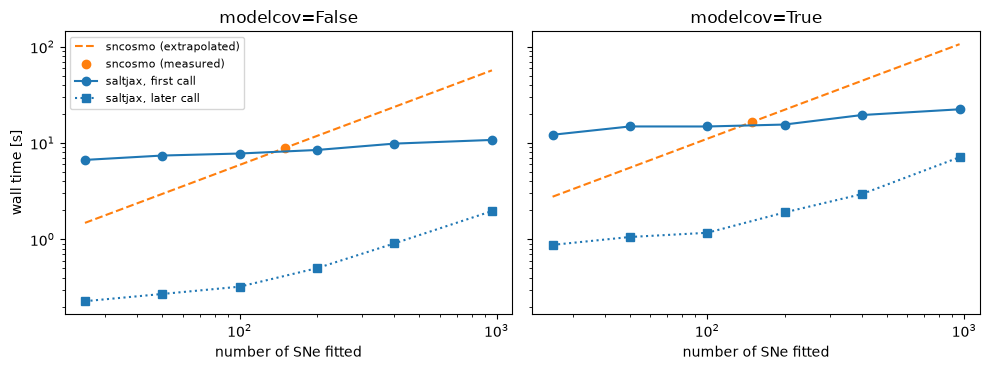

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
nn = np.geomspace(sizes[0], sizes[-1], 50)
for ax, modelcov in zip(axes, [False, True]):
    s = scaling[scaling["modelcov"] == modelcov]
    ax.plot(nn, sncosmo_per_sn[modelcov] * nn, "--", color="C1", label="sncosmo (extrapolated)")
    ax.plot(NSUB, sncosmo_per_sn[modelcov] * NSUB, "o", color="C1", label="sncosmo (measured)")
    ax.plot(s["N"], s["saltjax first [s]"], "o-", color="C0", label="saltjax, first call")
    ax.plot(s["N"], s["saltjax later [s]"], "s:", color="C0", label="saltjax, later call")
    ax.set(xscale="log", yscale="log", xlabel="number of SNe fitted", title=f"modelcov={modelcov}")
axes[0].set_ylabel("wall time [s]")
axes[0].legend(fontsize=8)
fig.tight_layout()

Where does a first saltjax call become faster than sncosmo? We look for the crossing of the measured first-call times
with the extrapolated sncosmo line (linear interpolation between the measured sizes).

In [11]:
def break_even(s, per_sn):
    diff = s["saltjax first [s]"].to_numpy() - per_sn * s["N"].to_numpy()
    n = s["N"].to_numpy()
    if diff[0] < 0:
        return f"< {n[0]}"
    i = np.flatnonzero(diff < 0)
    if len(i) == 0:
        return f"> {n[-1]}"
    i = i[0]
    return f"~{n[i - 1] + (n[i] - n[i - 1]) * diff[i - 1] / (diff[i - 1] - diff[i]):.0f}"

pd.Series({f"modelcov={m}": break_even(scaling[scaling["modelcov"] == m], sncosmo_per_sn[m]) for m in (False, True)},
          name="break-even number of SNe (first call)")

modelcov=False    ~135
modelcov=True     ~136
Name: break-even number of SNe (first call), dtype: str

The first-call time is mostly fixed costs. Between 25 and about 960 SNe it only grows from about 7 to 11 s without model covariance, and from 12 to 22 s with it.
This is because the number of buckets, and so of compilations, grows slowly with the sample. sncosmo's time grows linearly with the number of SNe.
So for a single fit of a small sample in a fresh session (below about 135 SNe here), sncosmo is faster. Above that, saltjax wins even when it pays for compilation.
Later calls are faster than sncosmo at every size measured, from 25 SNe on.

## Tips

### One big call rather than many small ones

Pass all your SNe to a single {func}`saltjax.fit_salt` call. Each batch is padded to a fixed size, so a small call also fits padding copies.
Each call also gets the model tables for its own redshift range (rounded to 0.01) and Milky Way E(B-V) range (rounded to 0.1).
When those ranges change, the tables change shape and the fit is compiled again.
Here we fit the full sample in one call, then in chunks of 50 SNe, with `modelcov=False`. The one-call shapes are compiled beforehand:

In [12]:
saltjax.fit_salt(data, targets, modelcov=False)    # make sure the one-call shapes are compiled
t = time.perf_counter()
saltjax.fit_salt(data, targets, modelcov=False)
one_call = time.perf_counter() - t
ncomp, ntab = len(saltjax.fitter._COMPILED), saltjax.tables._cached_tables.cache_info().misses
t = time.perf_counter()
for start in range(0, len(index), 50):
    saltjax.fit_salt(data, targets, indexes=index[start:start + 50], modelcov=False)
chunked = time.perf_counter() - t
print(f"one call: {one_call:.1f} s | {int(np.ceil(len(index) / 50))} calls of 50 SNe: {chunked:.1f} s, "
      f"which built {saltjax.tables._cached_tables.cache_info().misses - ntab} new tables "
      f"and compiled {len(saltjax.fitter._COMPILED) - ncomp} new functions")

one call: 2.2 s | 20 calls of 50 SNe: 42.7 s, which built 14 new tables and compiled 28 new functions


### Reuse within a session

Tables and compiled functions are cached in memory for the whole Python session: the first call pays for them, later calls do not
(compare the first and later calls above). A notebook or script that fits several samples should do so in the same process.
The compiled functions depend on the bucket lengths, `batch_points`, `modelcov`, `nrefit`, and the bands, redshift range and E(B-V) range of the tables
(through the table shapes); a later call that needs a new combination compiles it.

### JAX persistent compilation cache

JAX can also store compiled functions on disk, so that a *new* process does not recompile them:
```python
jax.config.update("jax_compilation_cache_dir", "/path/to/cache")
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
```
To measure its effect, we run the same small script twice in fresh Python processes, sharing one cache directory: it fits 200 SNe with
`modelcov=True` and prints the time of the `fit_salt` call (the tables are still rebuilt in each process).

In [13]:
script = """
import sys, time, pandas, jax
jax.config.update("jax_compilation_cache_dir", sys.argv[1])
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
import saltjax
data, targets = pandas.read_pickle(sys.argv[2]), pandas.read_pickle(sys.argv[3])
t = time.perf_counter()
saltjax.fit_salt(data, targets, modelcov=True)
print(time.perf_counter() - t)
"""
with tempfile.TemporaryDirectory() as tmp:
    sub = order[:200]
    data.loc[sub].to_pickle(f"{tmp}/data.pkl"); targets.loc[sub].to_pickle(f"{tmp}/targets.pkl")
    with open(f"{tmp}/fit.py", "w") as f:
        f.write(script)
    runs = [float(subprocess.run([sys.executable, f"{tmp}/fit.py", f"{tmp}/cache", f"{tmp}/data.pkl", f"{tmp}/targets.pkl"],
                                 capture_output=True, text=True, check=True).stdout.split()[-1]) for _ in range(2)]
print(f"fit_salt in a new process: {runs[0]:.1f} s (empty disk cache), {runs[1]:.1f} s (disk cache filled by the first run)")

fit_salt in a new process: 15.0 s (empty disk cache), 10.1 s (disk cache filled by the first run)


With the disk cache, the `fit_salt` call in a new process is about a third faster (15.0 s, then 10.1 s).
Loading the compiled functions from disk replaces most of the compilation, but each process still builds the tables and packs the data.
This helps scripts that are run many times on similar samples. The cache directory grows with every new shape compiled.

### `batch_points`

Lightcurves with at most $L$ points (after bucketing) are fitted by batches of `batch_points // L` SNe (default `batch_points=2048`).
Larger batches mean fewer, bigger computations (better use of a GPU, or of many CPU cores) but more padding when a bucket
holds few SNe, and more memory. Each value of `batch_points` is compiled separately. The default is a reasonable choice on a CPU; it was not tuned here.

### CPU or GPU

Everything on this page ran on a CPU. saltjax runs unchanged on a GPU (install a CUDA-enabled `jaxlib`), where the batched fits
should be faster, but **we did not measure it here**.

## Hardware and software

So that you can compare with your own machine:

In [14]:
cpu = platform.processor()
if sys.platform == "darwin":
    cpu = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True).stdout.strip() or cpu
elif os.path.exists("/proc/cpuinfo"):
    cpu = next((l.split(":", 1)[1].strip() for l in open("/proc/cpuinfo") if l.startswith("model name")), cpu)
print(f"{cpu}, {os.cpu_count()} cores, {platform.system()} {platform.release()}, JAX device: {jax.devices()[0].platform}")
print(f"python {platform.python_version()} | saltjax {saltjax.__version__} | jax {jax.__version__} | "
      f"sncosmo {sncosmo.__version__} | numpy {np.__version__} | skysurvey {skysurvey.__version__}")

Apple M1 Max, 10 cores, Darwin 25.5.0, JAX device: cpu
python 3.13.14 | saltjax 0.1.0 | jax 0.10.2 | sncosmo 2.13.0 | numpy 2.4.6 | skysurvey 1.4.0


## Next steps

* [Quickstart](../quickstart.ipynb): fit your first lightcurves with saltjax.
* [Validation](./validation.ipynb): saltjax reproduces `sncosmo.fit_lc`.
* [API reference](../api/index.rst).